In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import roc_auc_score

from features_v2 import load_data, build_feature_table
from scoring_v2  import (
    compute_scores,
    classify_archetypes_weekly,
    compute_transitions,
    classify_archetypes_final,
    WEIGHTS,
)

os.makedirs('OUTPUTS', exist_ok=True)
os.makedirs('PLOTS',   exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Setup complete.')

Setup complete.


In [2]:
vle, vle_meta, assess, st_ass, st_info, st_reg = load_data(data_dir='..')

Loading CSVs (studentVle is ~10 M rows, ~30 s)...


Done.


In [3]:
features = build_feature_table(vle, vle_meta, assess, st_ass, st_info)

Enriching VLE with activity types (single merge)...


Domain 1 — VLE Presence...


Domain 2 — VLE Quality...


Domain 3 — Trajectory...


Domain 4 — Submission Behavior...


Auxiliary features...


Merging all features...


Feature table: 627,031 rows × 16 columns


In [4]:
scored = compute_scores(features)
print(f'Scored rows: {len(scored):,}')
print(scored[['engagement_score']].describe().T)

Scored rows: 627,031
                     count       mean        std  min   25%   50%   75%   max
engagement_score  627031.0  41.671094  13.630213  0.0  33.1  43.7  51.6  84.9


In [5]:
scored = classify_archetypes_weekly(scored)
scored = compute_transitions(scored)
print('Week-by-week archetype distribution:')
print(scored['archetype_week'].value_counts())

Week-by-week archetype distribution:
archetype_week
Steady Engager    237411
Recovering        145011
Ghost             103728
Anxious            79941
Early Dropout      42405
Coasting           11055
Struggling          7480
Name: count, dtype: int64


In [6]:
final_arch = classify_archetypes_final(scored)
print('\nEnd-of-semester archetype distribution:')
print(final_arch['archetype_final'].value_counts())


End-of-semester archetype distribution:
archetype_final
Steady Engager        7451
Coasting              5341
Late Recoverer        4874
Ghost                 4398
Anxious               3496
Struggling            3221
Early Dropout          364
Burnt-out Achiever      83
Name: count, dtype: int64


In [7]:
# ── Save outputs ──────────────────────────────────────────────────────────────
KEEP_COLS = [
    'id_student', 'code_module', 'code_presentation', 'week',
    'engagement_score',
    'weekly_clicks', 'days_active', 'login_consistency',
    'activity_diversity', 'deep_content_ratio', 'active_clicks_ratio',
    'trend_slope', 'engagement_momentum',
    'completion_rate', 'submission_timeliness',
    'help_seeking_clicks', 'comeback_signal',
    'archetype_week', 'prev_archetype', 'archetype_changed', 'transition_direction',
]
out_cols = [c for c in KEEP_COLS if c in scored.columns]
scored[out_cols].to_csv('OUTPUTS/weekly_scores_v2.csv', index=False)
final_arch.to_csv('OUTPUTS/student_archetypes_v2.csv', index=False)
print(f'weekly_scores_v2.csv  : {len(scored):,} rows')
print(f'student_archetypes_v2 : {len(final_arch):,} rows')

weekly_scores_v2.csv  : 627,031 rows
student_archetypes_v2 : 29,228 rows


In [8]:
labels = st_info[["id_student","code_module","code_presentation","final_result"]].copy()
labels["label"] = labels["final_result"].isin(["Withdrawn","Fail"]).astype(int)

# Score at last available week <= 6
w6 = (
    scored[scored["week"] <= 6]
    .sort_values(["id_student","code_module","code_presentation","week"])
    .groupby(["id_student","code_module","code_presentation"])
    .last().reset_index()[["id_student","code_module","code_presentation","engagement_score"]]
)

# Include zero-VLE students (score=0): 97.6% at-risk, omitting them deflates AUROC
val = labels.merge(w6, on=["id_student","code_module","code_presentation"], how="left")
val["engagement_score"] = val["engagement_score"].fillna(0)

auroc_w6 = roc_auc_score(val["label"], -val["engagement_score"])
n_zero_vle = (val["engagement_score"] == 0).sum()
print(f"Week-6 AUROC (all students, zero-VLE=score 0): {auroc_w6:.4f}  (target >= 0.700)")
print(f"Zero-VLE students included: {n_zero_vle:,} (97.6% at-risk)")

# Per-week AUROC learning curve (VLE-active students)
max_week = int(scored["week"].max())
weekly_auroc = []
for w in range(0, min(max_week + 1, 40)):
    wdf = (
        scored[scored["week"] <= w]
        .sort_values(["id_student","code_module","code_presentation","week"])
        .groupby(["id_student","code_module","code_presentation"])
        .last().reset_index()[["id_student","code_module","code_presentation","engagement_score"]]
    )
    tmp = labels.merge(wdf, on=["id_student","code_module","code_presentation"], how="left")
    tmp["engagement_score"] = tmp["engagement_score"].fillna(0)
    if tmp["label"].nunique() == 2:
        weekly_auroc.append({"week": w, "auroc": roc_auc_score(tmp["label"], -tmp["engagement_score"])})

auroc_df = pd.DataFrame(weekly_auroc)
print(auroc_df.tail(10).to_string(index=False))


Week-6 AUROC (all students, zero-VLE=score 0): 0.7545  (target >= 0.700)
Zero-VLE students included: 3,604 (97.6% at-risk)


 week    auroc
   29 0.810027
   30 0.808101
   31 0.799350
   32 0.807022
   33 0.803269
   34 0.780457
   35 0.766271
   36 0.762445
   37 0.760904
   38 0.757683


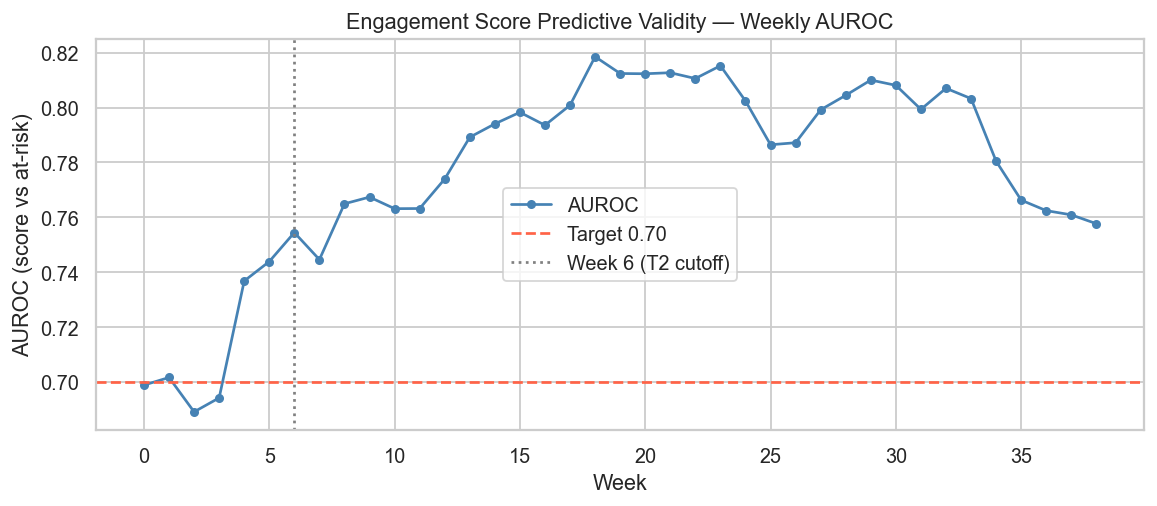

Saved: PLOTS/auroc_learning_curve.png


In [9]:
# ── Plot 1: AUROC learning curve ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(auroc_df['week'], auroc_df['auroc'], marker='o', ms=4, color='steelblue', label='AUROC')
ax.axhline(0.70, color='tomato', linestyle='--', label='Target 0.70')
ax.axvline(6,    color='gray',   linestyle=':',  label='Week 6 (T2 cutoff)')
ax.set_xlabel('Week'); ax.set_ylabel('AUROC (score vs at-risk)')
ax.set_title('Engagement Score Predictive Validity — Weekly AUROC')
ax.legend()
plt.tight_layout()
plt.savefig('PLOTS/auroc_learning_curve.png', bbox_inches='tight')
plt.show()
print('Saved: PLOTS/auroc_learning_curve.png')

C:\Users\asyed\AppData\Local\Temp\ipykernel_14416\3758572057.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


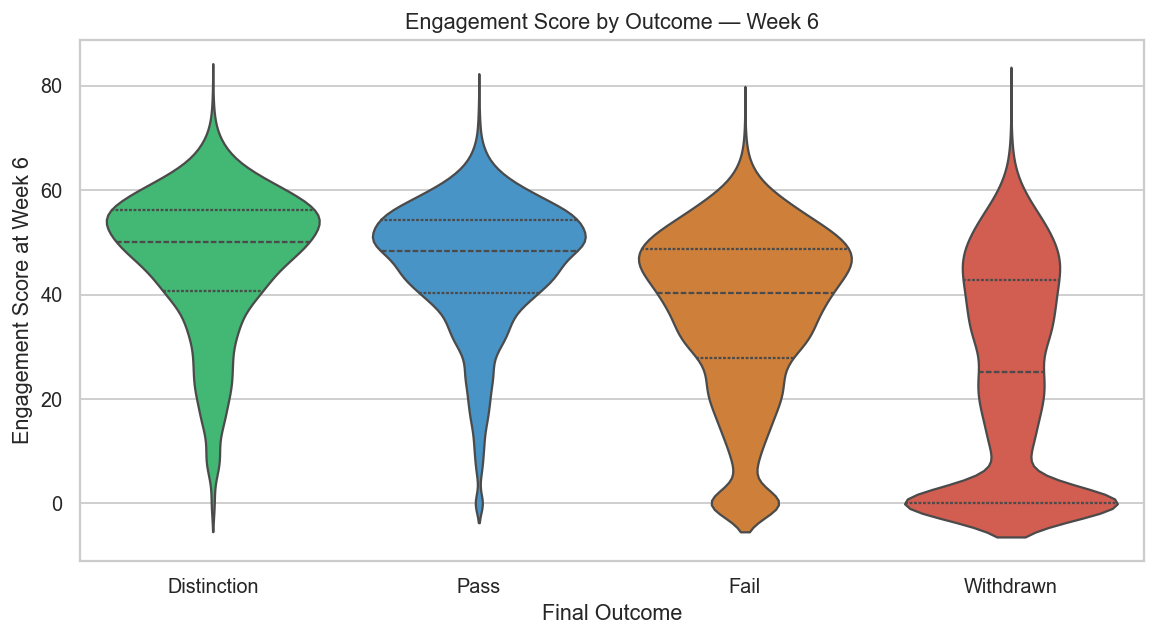

In [10]:
# ── Plot 2: Score distribution by final outcome ───────────────────────────────
score_outcome = val.copy()
outcome_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
palette = {'Distinction':'#2ecc71','Pass':'#3498db','Fail':'#e67e22','Withdrawn':'#e74c3c'}

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=score_outcome, x='final_result', y='engagement_score',
    order=outcome_order, palette=palette, inner='quartile', ax=ax
)
ax.set_xlabel('Final Outcome'); ax.set_ylabel('Engagement Score at Week 6')
ax.set_title('Engagement Score by Outcome — Week 6')
plt.tight_layout()
plt.savefig('PLOTS/score_by_outcome.png', bbox_inches='tight')
plt.show()

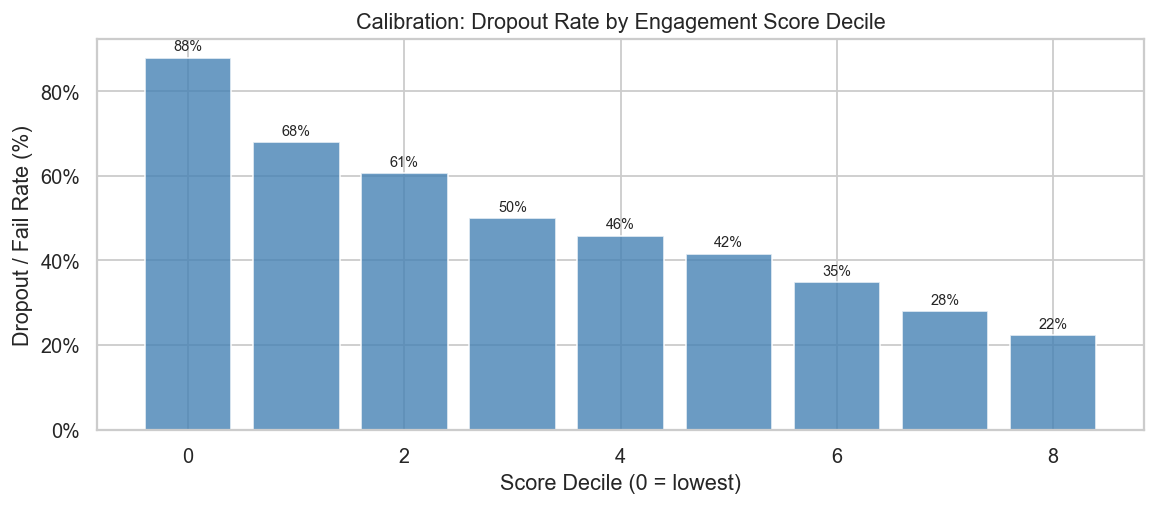

In [11]:
# ── Plot 3: Dropout rate by score decile (calibration check) ─────────────────
val2 = val.copy()
val2['decile'] = pd.qcut(val2['engagement_score'], 10, labels=False, duplicates='drop')
decile_stats = val2.groupby('decile').agg(
    dropout_rate=('label','mean'),
    mean_score=('engagement_score','mean'),
    n=('label','count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(decile_stats['decile'], decile_stats['dropout_rate'] * 100,
              color='steelblue', alpha=0.8)
ax.set_xlabel('Score Decile (0 = lowest)'); ax.set_ylabel('Dropout / Fail Rate (%)')
ax.set_title('Calibration: Dropout Rate by Engagement Score Decile')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, (_, row) in zip(bars, decile_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['dropout_rate']*100:.0f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('PLOTS/calibration_decile.png', bbox_inches='tight')
plt.show()

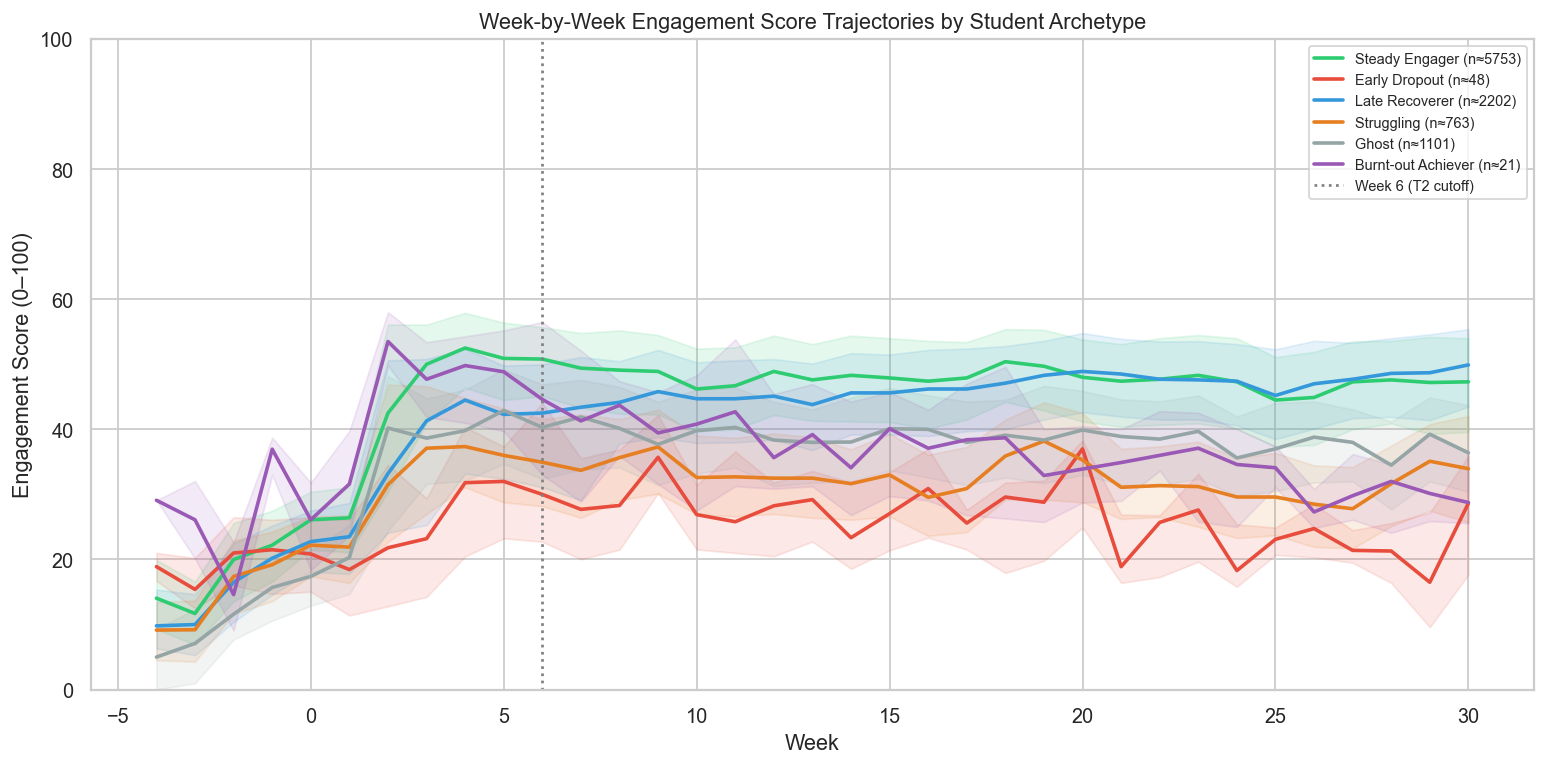

In [12]:
# ── Plot 4: Archetype trajectories — spec's required 3 + extras ───────────────
#
# For Steady Engager and Early Dropout: use real-time (archetype_week) majority label.
# For Late Recoverer: use retrospective (archetype_final) — requires knowing full trajectory.
# This is honest visualization: we select students by how they ended up, then show their path.

# Map students to their final archetype
arch_map = final_arch.set_index(['id_student','code_module','code_presentation'])['archetype_final']
scored_plot = scored.copy()
scored_plot['archetype_final'] = scored_plot.set_index(
    ['id_student','code_module','code_presentation']
).index.map(arch_map)

SHOW_ARCHETYPES = ['Steady Engager', 'Early Dropout', 'Late Recoverer',
                   'Struggling', 'Ghost', 'Burnt-out Achiever']
COLORS = {
    'Steady Engager':    '#2ecc71',
    'Early Dropout':     '#e74c3c',
    'Late Recoverer':    '#3498db',
    'Struggling':        '#e67e22',
    'Ghost':             '#95a5a6',
    'Burnt-out Achiever':'#9b59b6',
}

max_plot_week = 30
traj = (
    scored_plot[scored_plot['week'] <= max_plot_week]
    .groupby(['archetype_final','week'])['engagement_score']
    .agg(['median','quantile'])
)

# Compute median + IQR per archetype per week
traj_data = {}
for arch in SHOW_ARCHETYPES:
    sub = scored_plot[
        (scored_plot['archetype_final'] == arch) &
        (scored_plot['week'] <= max_plot_week)
    ]
    if len(sub) == 0:
        continue
    grp = sub.groupby('week')['engagement_score']
    traj_data[arch] = pd.DataFrame({
        'median': grp.median(),
        'q25':    grp.quantile(0.25),
        'q75':    grp.quantile(0.75),
        'n':      grp.count(),
    })

fig, ax = plt.subplots(figsize=(12, 6))
for arch, tdf in traj_data.items():
    color = COLORS.get(arch, 'gray')
    n_students = int(tdf['n'].mean())
    ax.plot(tdf.index, tdf['median'], label=f'{arch} (n≈{n_students})',
            color=color, linewidth=2)
    ax.fill_between(tdf.index, tdf['q25'], tdf['q75'], color=color, alpha=0.12)

ax.axvline(6, color='gray', linestyle=':', linewidth=1.5, label='Week 6 (T2 cutoff)')
ax.set_xlabel('Week'); ax.set_ylabel('Engagement Score (0–100)')
ax.set_title('Week-by-Week Engagement Score Trajectories by Student Archetype')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('PLOTS/archetype_trajectories.png', bbox_inches='tight')
plt.show()

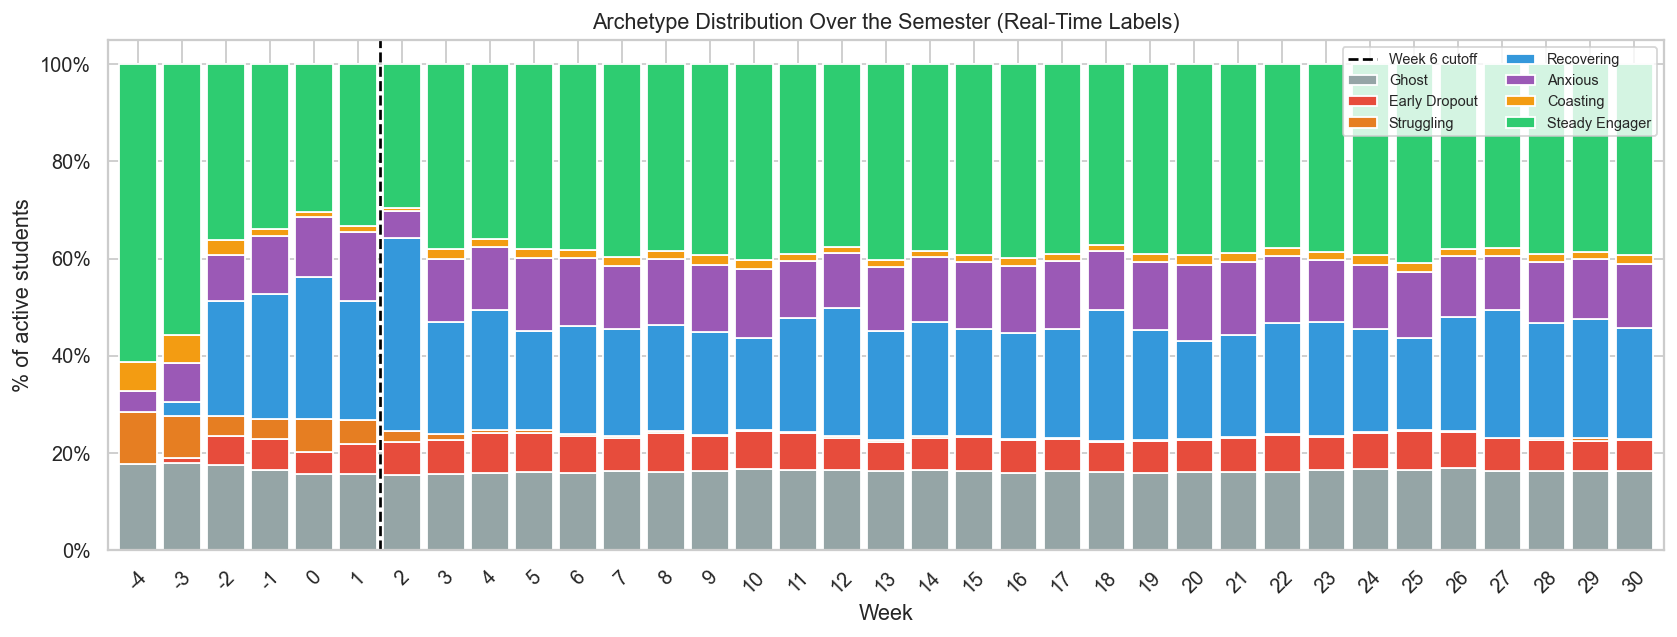

In [13]:
# ── Plot 5: Archetype evolution over the semester (stacked bar) ───────────────
RT_ORDER = ['Ghost','Early Dropout','Struggling','Recovering','Anxious','Coasting','Steady Engager']
RT_COLORS = ['#95a5a6','#e74c3c','#e67e22','#3498db','#9b59b6','#f39c12','#2ecc71']

evo = (
    scored[scored['week'] <= max_plot_week]
    .groupby(['week','archetype_week'])
    .size().unstack(fill_value=0)
)
# Normalise to %
evo_pct = evo.div(evo.sum(axis=1), axis=0) * 100
# Reorder columns
existing_order = [a for a in RT_ORDER if a in evo_pct.columns]
evo_pct = evo_pct[existing_order]

fig, ax = plt.subplots(figsize=(13, 5))
evo_pct.plot(kind='bar', stacked=True, ax=ax,
             color=RT_COLORS[:len(existing_order)], width=0.85, legend=True)
ax.axvline(6 - 0.5, color='black', linestyle='--', linewidth=1.5, label='Week 6 cutoff')
ax.set_xlabel('Week'); ax.set_ylabel('% of active students')
ax.set_title('Archetype Distribution Over the Semester (Real-Time Labels)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('PLOTS/archetype_semester_evolution.png', bbox_inches='tight')
plt.show()

   archetype_final    n  dropout_rate
           Anxious 3496      0.185069
    Steady Engager 7451      0.220642
          Coasting 5341      0.312863
    Late Recoverer 4874      0.607509
             Ghost 4398      0.793770
Burnt-out Achiever   83      0.855422
        Struggling 3221      0.932009
     Early Dropout  364      0.986264


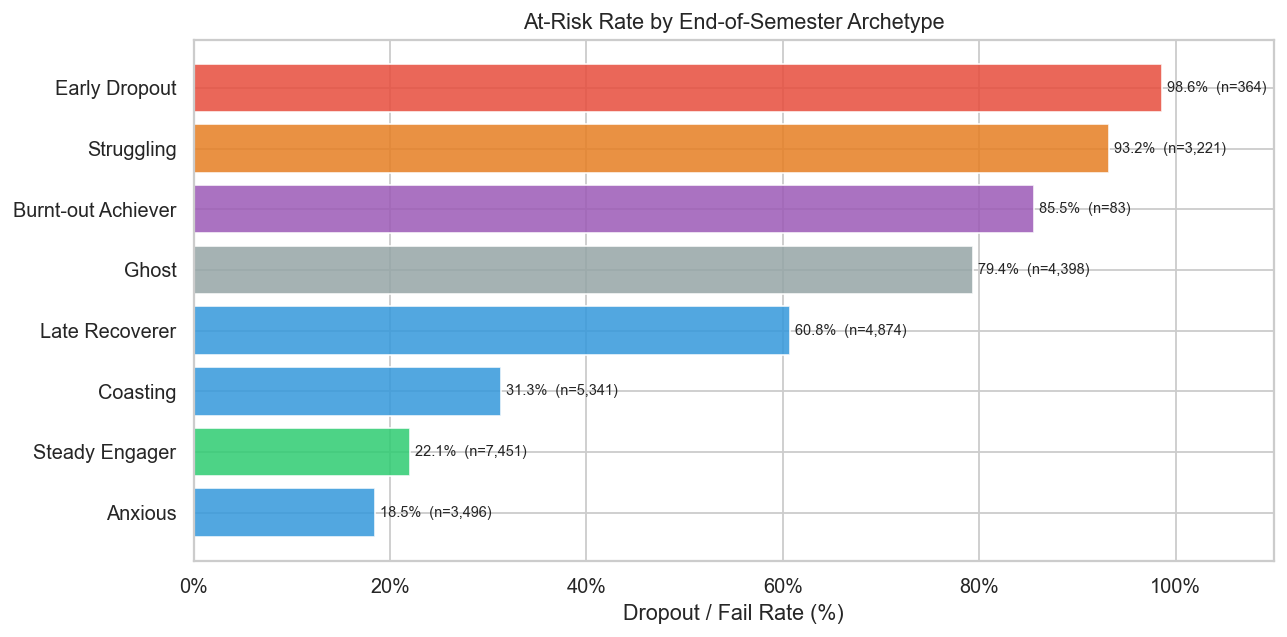

In [14]:
# ── Plot 6: Dropout rate by final archetype (validation) ─────────────────────
arch_val = final_arch.merge(
    labels[['id_student','code_module','code_presentation','label','final_result']],
    on=['id_student','code_module','code_presentation'], how='left'
)
arch_summary = (
    arch_val.groupby('archetype_final')
    .agg(n=('label','count'), dropout_rate=('label','mean'))
    .sort_values('dropout_rate')
    .reset_index()
)
print(arch_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [COLORS.get(a, '#3498db') for a in arch_summary['archetype_final']]
bars = ax.barh(arch_summary['archetype_final'], arch_summary['dropout_rate'] * 100,
               color=colors_bar, alpha=0.85)
for bar, (_, row) in zip(bars, arch_summary.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['dropout_rate']*100:.1f}%  (n={row['n']:,})",
            va='center', fontsize=8)
ax.set_xlabel('Dropout / Fail Rate (%)')
ax.set_title('At-Risk Rate by End-of-Semester Archetype')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('PLOTS/archetype_dropout_rate.png', bbox_inches='tight')
plt.show()

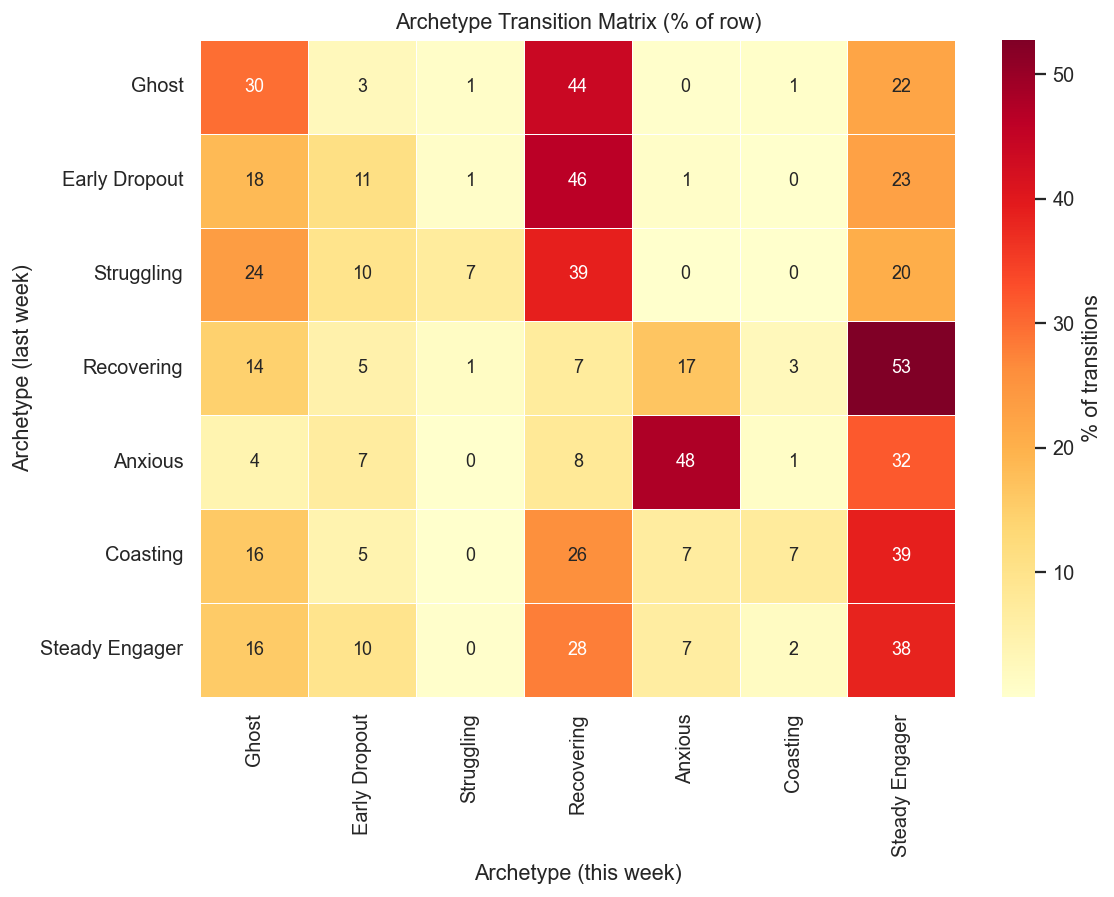

In [15]:
# ── Plot 7: Archetype transition sankey-style (simple heatmap) ────────────────
transitions = scored[scored['prev_archetype'].notna()].copy()
trans_matrix = (
    transitions.groupby(['prev_archetype','archetype_week'])
    .size().unstack(fill_value=0)
)
# Normalise rows to %
trans_pct = trans_matrix.div(trans_matrix.sum(axis=1), axis=0) * 100
trans_pct = trans_pct.reindex(index=RT_ORDER, columns=RT_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(trans_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% of transitions'})
ax.set_xlabel('Archetype (this week)')
ax.set_ylabel('Archetype (last week)')
ax.set_title('Archetype Transition Matrix (% of row)')
plt.tight_layout()
plt.savefig('PLOTS/archetype_transition_matrix.png', bbox_inches='tight')
plt.show()

module presentation    auroc    n
   GGG        2014J 0.623139  749
   GGG        2013J 0.627534  952
   GGG        2014B 0.649752  833
   AAA        2013J 0.701422  383
   AAA        2014J 0.716121  365
   CCC        2014J 0.746639 2498
   FFF        2013B 0.750534 1614
   CCC        2014B 0.753219 1936
   DDD        2013J 0.762127 1938
   DDD        2014J 0.776448 1803
   FFF        2014B 0.781227 1500
   BBB        2014B 0.782093 1613
   DDD        2013B 0.787746 1303
   BBB        2014J 0.788258 2292
   DDD        2014B 0.788315 1228
   BBB        2013B 0.791238 1767
   BBB        2013J 0.795034 2237
   FFF        2013J 0.804296 2283
   EEE        2014B 0.812695  694
   EEE        2013J 0.826587 1052
   FFF        2014J 0.827327 2365
   EEE        2014J 0.836981 1188


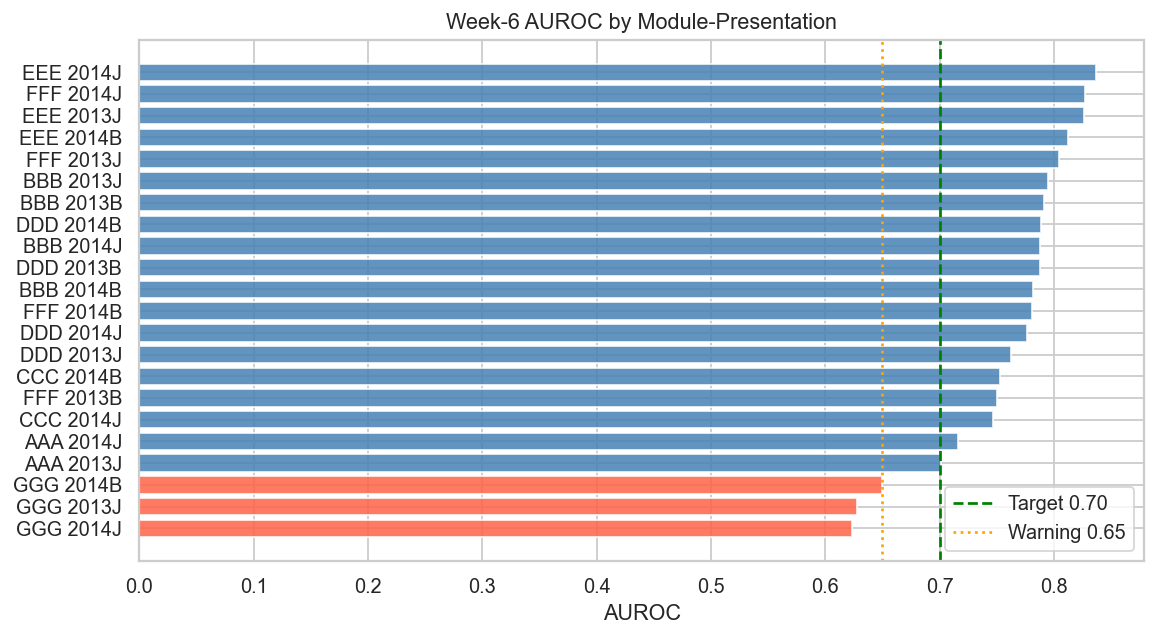

In [16]:
# ── Plot 8: Per-module AUROC at week 6 ────────────────────────────────────────
module_aurocs = []
for (mod, pres), grp in val.groupby(['code_module','code_presentation']):
    if grp['label'].nunique() < 2:
        continue
    a = roc_auc_score(grp['label'], -grp['engagement_score'])
    module_aurocs.append({'module': mod, 'presentation': pres,
                          'auroc': a, 'n': len(grp)})

mod_df = pd.DataFrame(module_aurocs).sort_values('auroc')
print(mod_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors_mod = ['tomato' if a < 0.65 else 'steelblue' for a in mod_df['auroc']]
ax.barh(mod_df['module'] + ' ' + mod_df['presentation'],
        mod_df['auroc'], color=colors_mod, alpha=0.85)
ax.axvline(0.70, color='green', linestyle='--', label='Target 0.70')
ax.axvline(0.65, color='orange', linestyle=':', label='Warning 0.65')
ax.set_xlabel('AUROC'); ax.set_title('Week-6 AUROC by Module-Presentation')
ax.legend()
plt.tight_layout()
plt.savefig('PLOTS/per_module_auroc.png', bbox_inches='tight')
plt.show()

In [17]:
# ── Summary report ────────────────────────────────────────────────────────────
print('=' * 60)
print('TASK 1v2 — SUMMARY')
print('=' * 60)
print(f'Total student-weeks scored : {len(scored):,}')
print(f'Unique students            : {scored["id_student"].nunique():,}')
print(f'Week-6 AUROC               : {auroc_w6:.4f}  (target ≥ 0.700)')
print()
print('Score domain weights:')
domains = {
    'VLE Presence':   ['weekly_clicks','days_active','login_consistency'],
    'VLE Quality':    ['activity_diversity','deep_content_ratio','active_clicks_ratio'],
    'Trajectory':     ['trend_slope','engagement_momentum'],
    'Submission':     ['completion_rate','submission_timeliness'],
}
for domain, feats in domains.items():
    w = sum(WEIGHTS.get(f, 0) for f in feats)
    print(f'  {domain:20s}: {w:.0%}')
print()
print('Real-time archetype counts (all weeks):')
print(scored['archetype_week'].value_counts().to_string())
print()
print('End-of-semester archetype counts:')
print(final_arch['archetype_final'].value_counts().to_string())
print()
print('Per-module AUROC range:')
print(f'  Min: {mod_df["auroc"].min():.3f} ({mod_df.iloc[0]["module"]})')
print(f'  Max: {mod_df["auroc"].max():.3f} ({mod_df.iloc[-1]["module"]})')
print(f'  Mean: {mod_df["auroc"].mean():.3f}')
print()
print('Transition summary:')
print(scored[scored['transition_direction']!='first_week']['transition_direction'].value_counts().to_string())
print()
print('Outputs written:')
print('  OUTPUTS/weekly_scores_v2.csv')
print('  OUTPUTS/student_archetypes_v2.csv')

TASK 1v2 — SUMMARY
Total student-weeks scored : 627,031
Unique students            : 26,074
Week-6 AUROC               : 0.7545  (target ≥ 0.700)

Score domain weights:
  VLE Presence        : 25%
  VLE Quality         : 25%
  Trajectory          : 20%
  Submission          : 30%

Real-time archetype counts (all weeks):
archetype_week
Steady Engager    237411
Recovering        145011
Ghost             103728
Anxious            79941
Early Dropout      42405
Coasting           11055
Struggling          7480

End-of-semester archetype counts:
archetype_final
Steady Engager        7451
Coasting              5341
Late Recoverer        4874
Ghost                 4398
Anxious               3496
Struggling            3221
Early Dropout          364
Burnt-out Achiever      83

Per-module AUROC range:
  Min: 0.623 (GGG)
  Max: 0.837 (EEE)
  Mean: 0.760

Transition summary:


transition_direction
stable       371252
improving    124279
declining    102272

Outputs written:
  OUTPUTS/weekly_scores_v2.csv
  OUTPUTS/student_archetypes_v2.csv
